# Diamond Price Prediction Project

## 1. Import Libraries

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## 2. Load Dataset

In [6]:
df = pd.read_csv("../data/diamonds.csv")

In [7]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [8]:
df.tail()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,53940,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64


## 3. Data Cleaning

In [9]:
df = df.drop(columns=["Unnamed: 0"])

In [10]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## 4. Dataset Inspection

In [11]:
df.shape

(53940, 10)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [13]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [14]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

In [15]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(146)

## 5. Exploratory Data Analysis (EDA)

### 5.1 Histogram

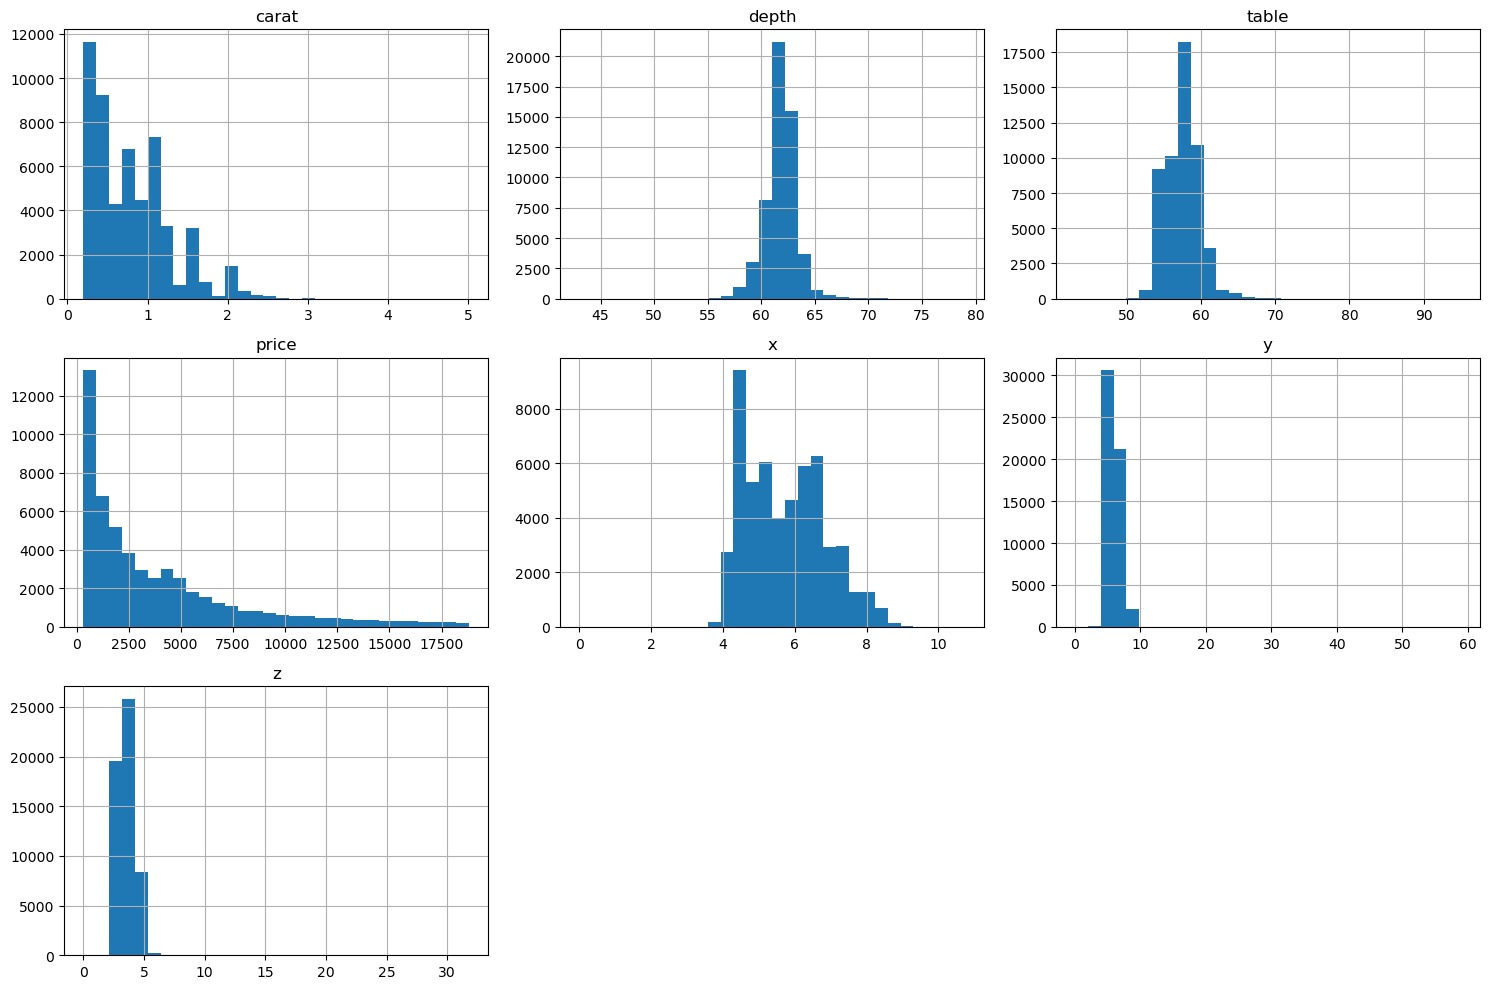

In [17]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[num_cols].hist(figsize=(15,10), bins=30)

plt.tight_layout()
plt.show()

### Distribution of Diamond Prices

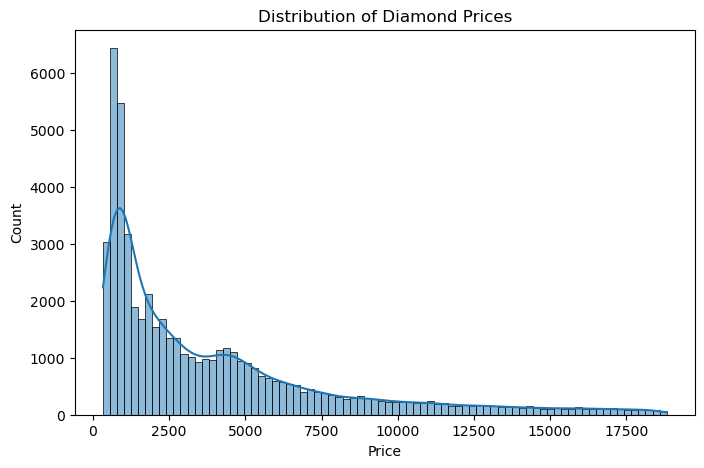

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], kde=True)

plt.title("Distribution of Diamond Prices")
plt.xlabel("Price")

plt.show()

### 5.2 Boxplot

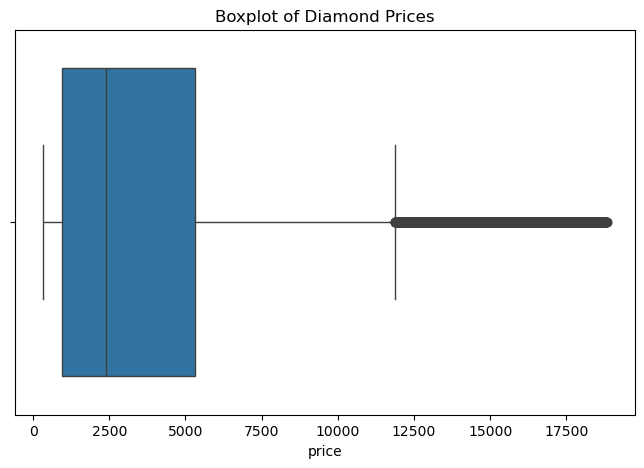

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["price"])

plt.title("Boxplot of Diamond Prices")

plt.show()

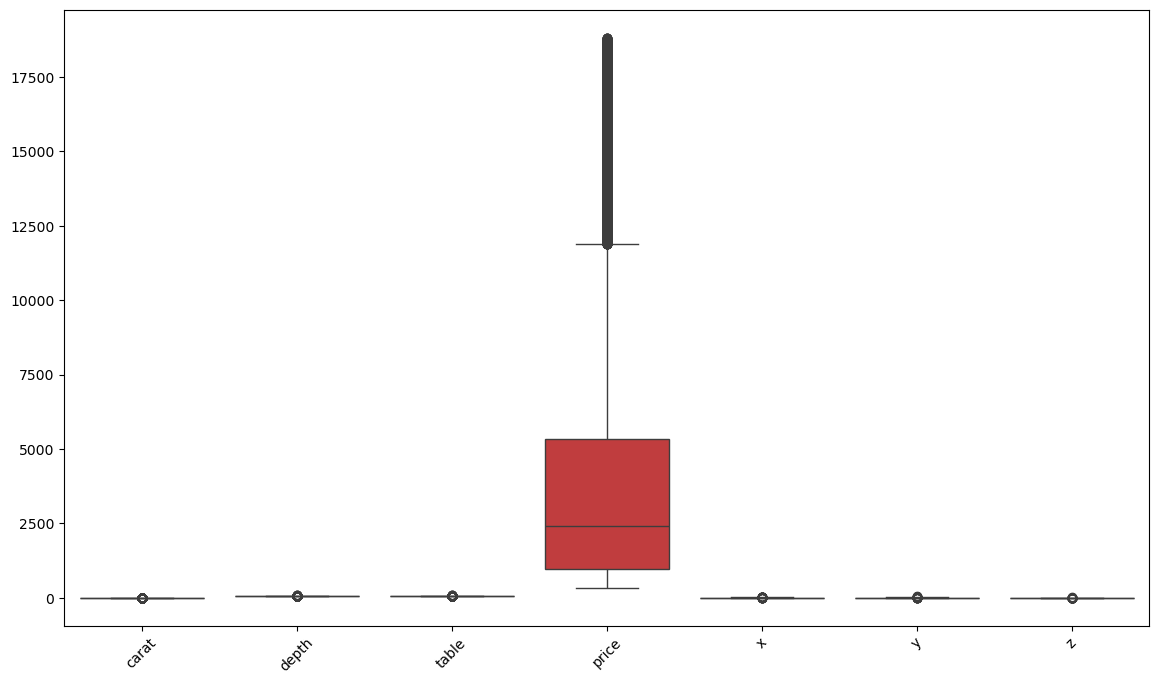

In [20]:
plt.figure(figsize=(14,8))

sns.boxplot(data=df.select_dtypes(include=["int64","float64"]))

plt.xticks(rotation=45)

plt.show()

### 5.3 Scatterplot

### Carat vs Price

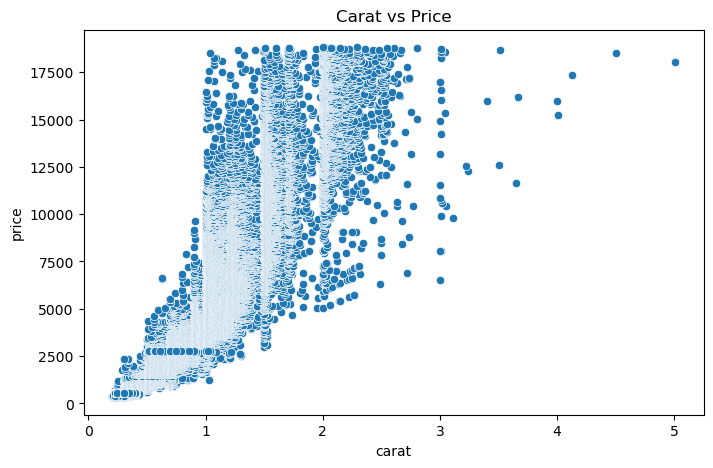

In [21]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="carat", y="price", data=df)

plt.title("Carat vs Price")

plt.show()

### Depth vs Price

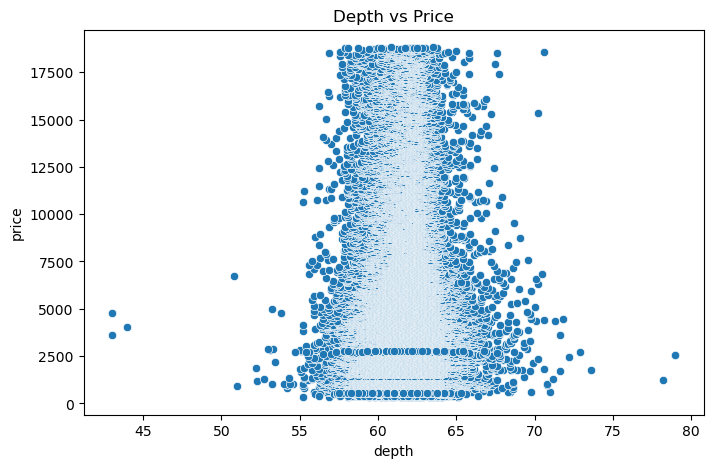

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="depth", y="price", data=df)

plt.title("Depth vs Price")

plt.show()


### Table vs Price

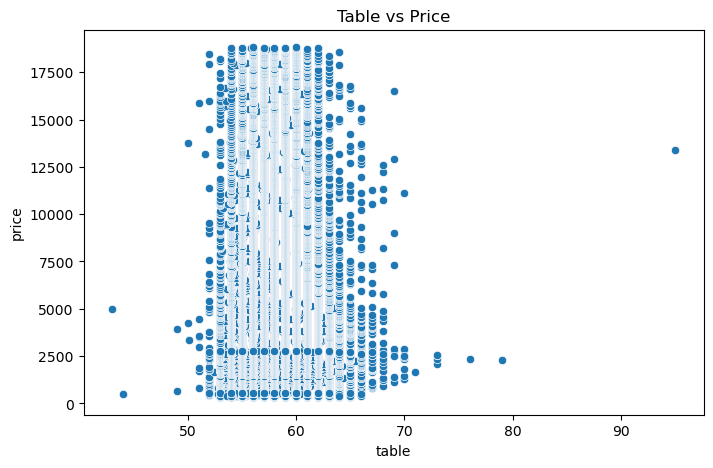

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="table", y="price", data=df)

plt.title("Table vs Price")

plt.show()

### 5.4 Corrrelation Heatmap

In [24]:
numeric_df = df.select_dtypes(include=np.number)

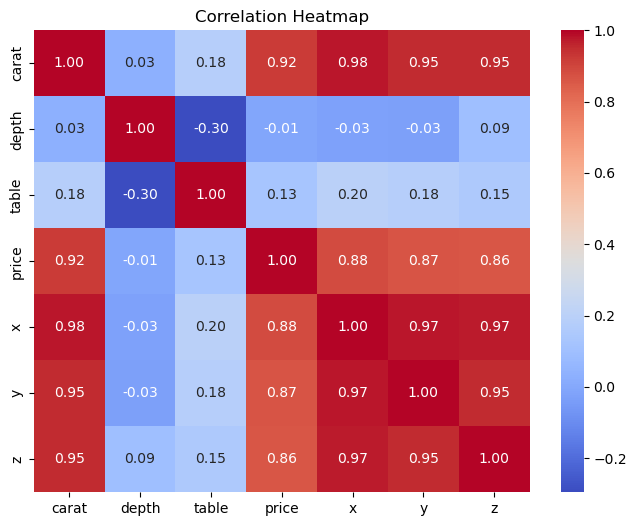

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### 5.5 pairplot

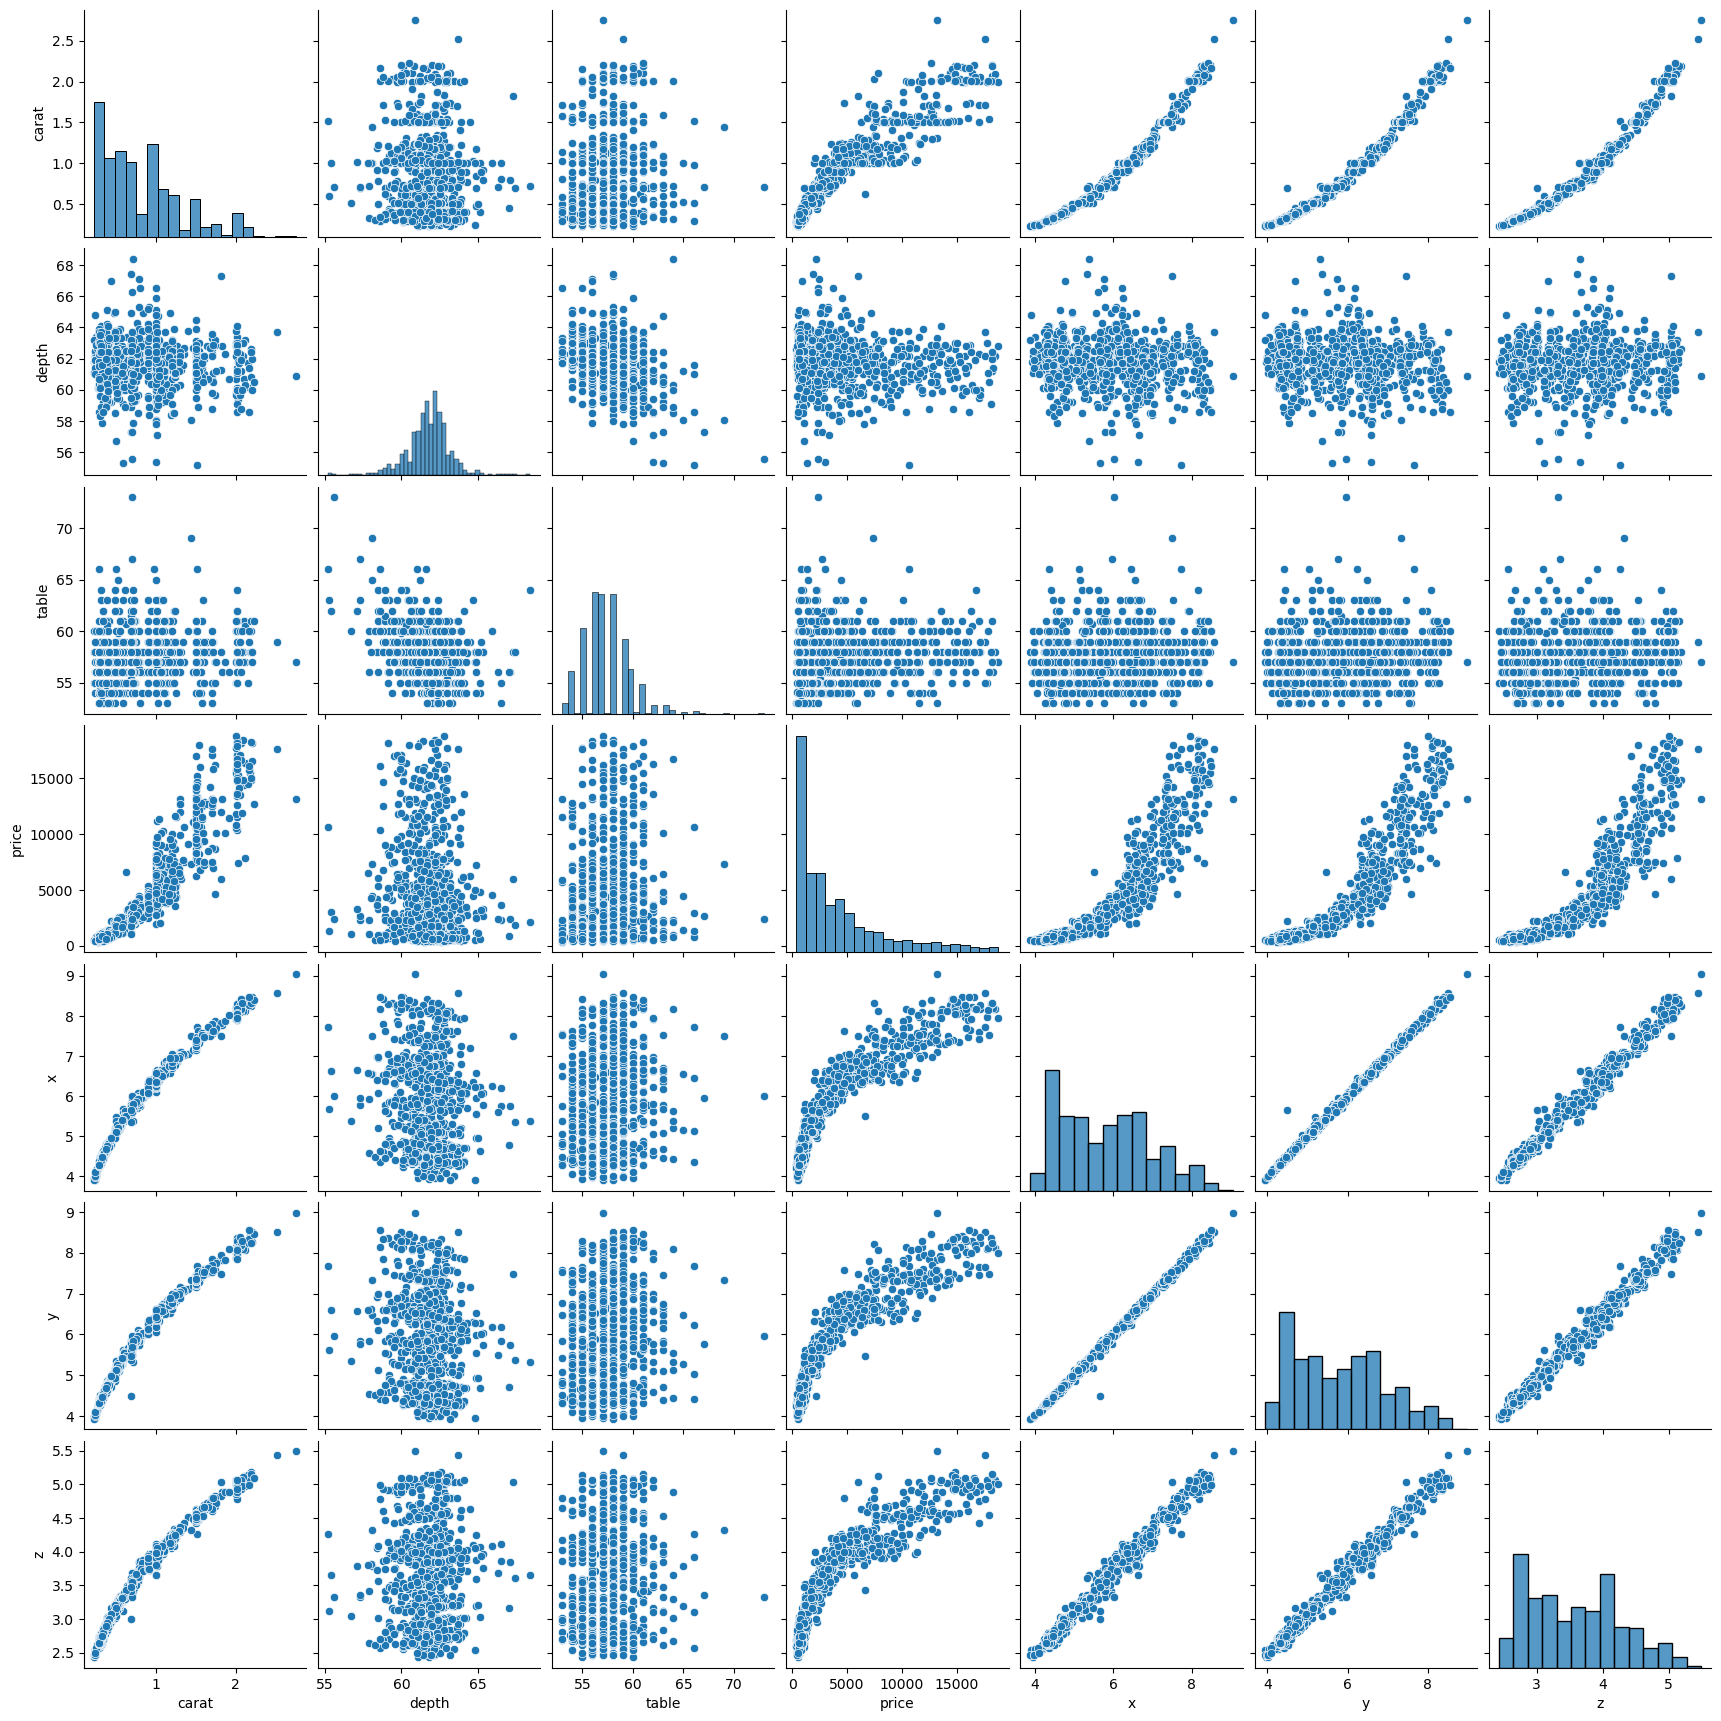

In [27]:
sample_df = df.sample(1000, random_state=42)

sns.pairplot(sample_df)

plt.show()

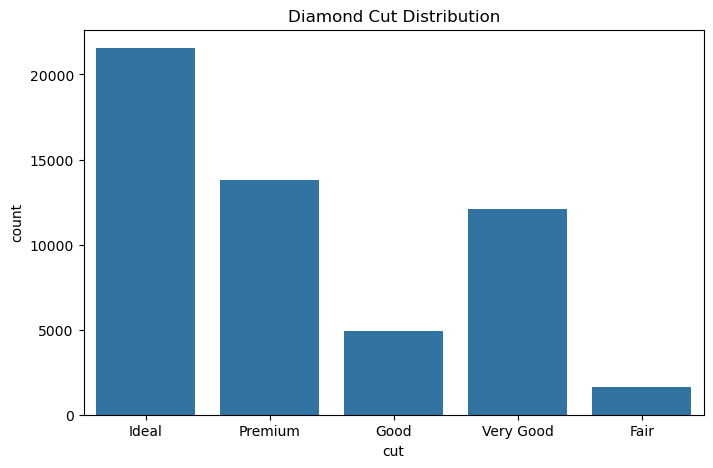

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(x="cut", data=df)

plt.title("Diamond Cut Distribution")

plt.show()

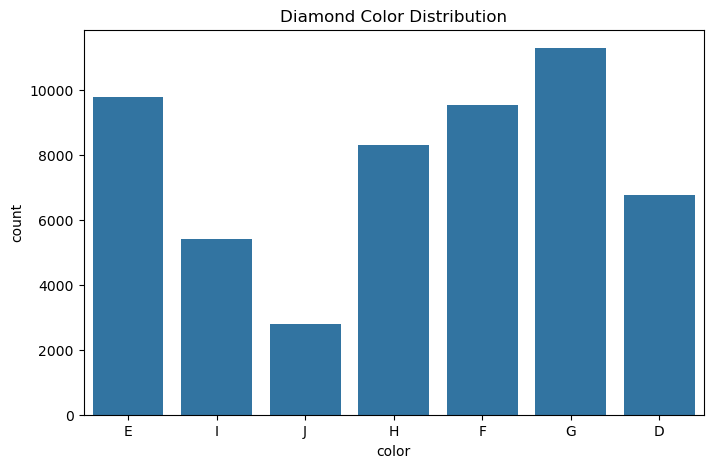

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(x="color", data=df)

plt.title("Diamond Color Distribution")

plt.show()


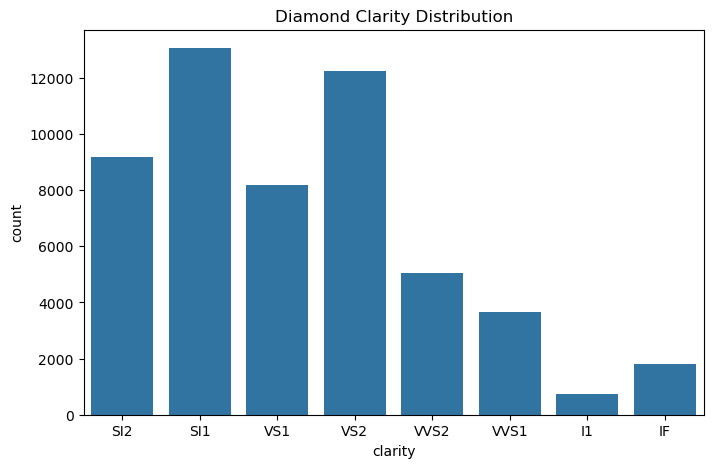

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(x="clarity", data=df)

plt.title("Diamond Clarity Distribution")

plt.show()

## 6. Data Preprocessing for Modeling

Before training machine learning models, the dataset must be prepared in a suitable format. 
This preprocessing stage involves separating the input features from the target variable, 
encoding categorical variables, scaling numerical features when necessary, and 
splitting the dataset into training and testing sets. These steps ensure that the models receive clean and 
consistent input data for training and evaluation.


## 6.1 Separate Features and Target

In [31]:
X = df.drop("price", axis=1)

y = df["price"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (53940, 9)
Target Shape: (53940,)


## 6.2 Identify Feature Types

In [32]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical Features:")
print(categorical_cols)

print("\nNumerical Features:")
print(numerical_cols)

Categorical Features:
Index(['cut', 'color', 'clarity'], dtype='object')

Numerical Features:
Index(['carat', 'depth', 'table', 'x', 'y', 'z'], dtype='object')


## 6.3 Encode Categorical Variables

In [33]:
encoder = OrdinalEncoder()

X[categorical_cols] = encoder.fit_transform(X[categorical_cols])

X.head()

,carat,cut,color,clarity,depth,table,x,y,z
0,0.23,2.0,1.0,3.0,61.5,55.0,3.95,3.98,2.43
1,0.21,3.0,1.0,2.0,59.8,61.0,3.89,3.84,2.31
2,0.23,1.0,1.0,4.0,56.9,65.0,4.05,4.07,2.31
3,0.29,3.0,5.0,5.0,62.4,58.0,4.20,4.23,2.63
4,0.31,1.0,6.0,3.0,63.3,58.0,4.34,4.35,2.75


## 6.4 Split Dataset into Training and Testing Sets

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (43152, 9)
Testing Set: (10788, 9)


## 6.5 Feature Scaling

In [35]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (43152, 9)
Scaled testing shape: (10788, 9)


# 7: Build and Evaluate Regression Models

## 7.1 Linear Regression

Linear Regression is used as the baseline regression model for predicting diamond prices. It estimates the relationship between the input features and the target variable by fitting a linear equation to the observed data. The model provides a reference point against which more advanced regression algorithms can be compared.

In [40]:
# Create the model
lr_model = LinearRegression()

In [41]:
lr_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
# Predict on the test set
y_pred_lr = lr_model.predict(X_test_scaled)

In [43]:
predictions = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred_lr
})

predictions.head(10)

,Actual Price,Predicted Price
1388,559,363.646688
50052,2201,3355.932308
41645,1238,2139.566064
42377,1304,2371.644610
17244,6901,10551.699188
1608,3011,5692.876770
46398,1765,1898.668082
45493,1679,2610.081088
49385,2102,3071.451463
10460,4789,5817.006690


In [45]:
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 858.71
MSE : 1825912.99
RMSE: 1351.26
R²  : 0.8851


### Model Evaluation

The Linear Regression model achieved an R² score of **0.8851**, indicating that it explains approximately **88.5%** of the variation in diamond prices. The model produced a Mean Absolute Error (MAE) of **858.71** and a Root Mean Squared Error (RMSE) of **1351.26**, suggesting that its predictions are reasonably close to the actual prices. Overall, Linear Regression provides a strong baseline model for this project and will serve as a benchmark when evaluating more advanced regression algorithms.


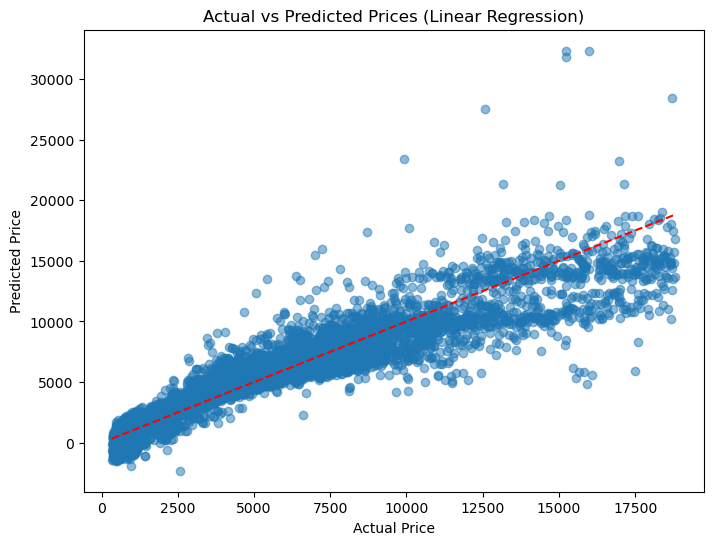

In [46]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_lr, alpha=0.5)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Linear Regression)")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.show()